In [61]:
from pathlib import *
from matplotlib import *
import pandas

In [90]:
# SLO is 500 microseconds
SERVICE_LEVEL_OBJECTIVE = 500

def parse_p99(directory : str) -> pandas.DataFrame:
    rows = []

    for path in Path(directory).iterdir():
        if not path.is_dir():
            continue
        
        log_file_path = path / 'leader.log'
        if not log_file_path.exists():
            continue

        queries_per_second = int(path.name.split("_")[1])

        with open(log_file_path) as log_file:
            raw_data    = log_file.readlines()

            read_p99   = float(raw_data[-11].split()[-1])
            update_p99 = float(raw_data[-10].split()[-1])

            rows.append({
                'qps':        queries_per_second,
                'read_p99':   read_p99,
                'update_p99': update_p99,
            })
    
    return pandas.DataFrame(rows).sort_values('qps').set_index('qps')

def graph_p99(directory : str) -> None:
    data_frame = parse_p99(directory)

    matplotlib.pyplot.plot(data_frame['read_p99'])
    matplotlib.pyplot.plot(data_frame['update_p99'])
    matplotlib.pyplot.ylim(bottom=0, top=1000)
    matplotlib.pyplot.axhline(y=SERVICE_LEVEL_OBJECTIVE, color='r', linestyle='--')
    matplotlib.pyplot.show()

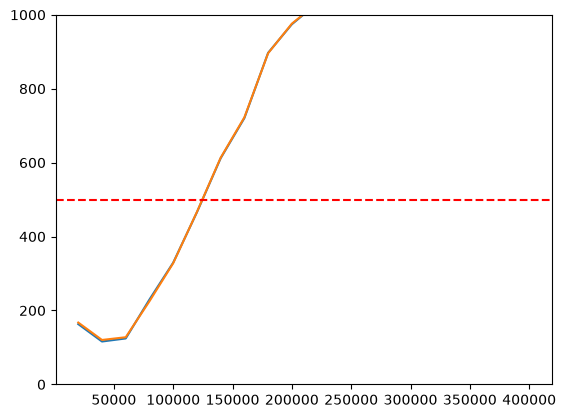

In [91]:
graph_p99("results")